![image.png](https://i.imgur.com/a3uAqnb.png)

# Test-Time Compute Scaling

- **Dataset**: [MATH-500](https://huggingface.co/datasets/HuggingFaceH4/MATH-500) from Hugging Face, 500 competition problems with LaTeX answers
- **Task**: competition mathematics, graded exactly with [Math-Verify](https://github.com/huggingface/Math-Verify)
- **Model**: the policy [Qwen/Qwen2.5-1.5B-Instruct](https://huggingface.co/Qwen/Qwen2.5-1.5B-Instruct) and the process reward model [Qwen/Qwen2.5-Math-PRM-7B](https://huggingface.co/Qwen/Qwen2.5-Math-PRM-7B), both used as they are (no training)
- **Runtime**: Colab A100 GPU with 80 GB of memory

In this lab, we will:

- build a step-wise generator that stops at the end of each reasoning step, and a scorer that reads a 7B process reward model
- implement majority voting, best-of-N and weighted best-of-N over one pool of samples
- implement beam search and diverse verifier tree search (DVTS) guided by the step scores
- plot accuracy against the generation budget $N$ for every method and read the cost of each

## What is test-time compute scaling?

Instead of a larger model, we spend more generation on each problem and then *select*. With $N$ sampled solutions $y^{(1)}, \dots, y^{(N)}$ to a problem $p$, their extracted answers $a_i$ and a scorer $v$, the three parallel selectors are

$$\underbrace{\arg\max_{i} v\big(y^{(i)}\big)}_{\text{best-of-N}} \qquad \underbrace{\arg\max_a \sum_{i} \mathbb{1}[a_i = a]}_{\text{majority vote}} \qquad \underbrace{\arg\max_a \sum_{i} v\big(y^{(i)}\big)\, \mathbb{1}[a_i = a]}_{\text{weighted best-of-N}}$$

The scorer is a process reward model (PRM). It reads the problem and a solution whose $K$ steps $s_1, \dots, s_K$ are marked by a separator token, and at the separator that ends step $k$ it outputs

$$r_{s_k} = \mathbb{P}(\text{step } k \text{ is correct} \mid p, s_1, \dots, s_k)$$

The $K$ step scores are reduced to one solution score $v(y)$ by the *last* step, the *minimum* or the *product*. Beam search uses the scores during generation: $N$ beams each write one step, the PRM scores every partial solution, the top $N/M$ survive and each is expanded $M$ ways. DVTS splits the $N$ beams into $N/M$ independent subtrees and keeps the best child inside each, which trades exploitation of the PRM for diversity.

Where:
- $N$ is the generation budget (solutions, or beams, per problem) and $M$ the beam width
- $v(y)$ is the aggregated PRM score of a solution and $a_i$ the boxed answer extracted by Math-Verify
- $r_{s_k}$ is the PRM's probability that step $k$ is correct given the steps before it

Papers: [Snell et al., 2024. Scaling LLM Test-Time Compute Optimally can be More Effective than Scaling Model Parameters](https://arxiv.org/abs/2408.03314), [Lightman et al., 2023. Let's Verify Step by Step](https://arxiv.org/abs/2305.20050), [Zhang et al., 2025. The Lessons of Developing Process Reward Models in Mathematical Reasoning](https://arxiv.org/abs/2501.07301)

## Setup

In [1]:
%pip install -q "math-verify[antlr4_13_2]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.1/209.1 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 15.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
omegaconf 2.3.1 requires antlr4-python3-runtime==4.9.*, but you have antlr4-python3-runtime 4.13.2 which is incompatible.


In [2]:
import json
import math
import random
import time
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datasets import load_dataset
from huggingface_hub import hf_hub_download
from math_verify import parse, verify
from safetensors import safe_open

import torch
import torch.nn as nn
from transformers import AutoModelForCausalLM, AutoModelForTokenClassification, AutoTokenizer, Qwen2Model

In [3]:
SEED = 42
POLICY = "Qwen/Qwen2.5-1.5B-Instruct"        # 1.5B, Apache-2.0, about 3 GB in bfloat16
PRM = "Qwen/Qwen2.5-Math-PRM-7B"             # 7.6B, Qwen licence, about 15 GB in bfloat16
PRM_SMALL = "HuggingFaceH4/Qwen2.5-Math-1.5B-Instruct-PRM-0.2"   # the fallback on a T4: a 1.5B TRL token classifier
N_TEST = 50                 # MATH-500 problems (level 3, where a 1.5B model is right about half the time)
LEVEL = 3
N_MAX = 32                  # samples per problem in the shared pool
NS = [1, 2, 4, 8, 16, 32]   # budgets read from the pool
SEARCH_NS = [4, 16]         # budgets for beam search and DVTS
BEAM_WIDTH = 4              # M: children per surviving beam
MAX_ITERATIONS = 6          # search depth in steps; the last iteration writes to the end
STEP_TOKENS = 128           # token budget for one step
MAX_NEW_TOKENS = 512        # token budget for a full solution
TEMPERATURE = 0.8           # search-and-learn default
BATCH_SIZE = 256            # prompts per generate call
PRM_BATCH_SIZE = 16         # solutions per PRM forward pass
AGG = "last"                # how K step scores become one solution score: "last", "min" or "prod"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch {torch.__version__} | device: {DEVICE}")
if DEVICE == "cuda":
    GPU_GB = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU: {torch.cuda.get_device_name(0)} ({GPU_GB:.1f} GB)")
else:
    GPU_GB = 0.0
    print("No GPU found, so generation will be very slow. In Colab: Runtime > Change runtime type > A100 GPU.")

# Inference only, so no gradient scaler: bfloat16 on an A100 or newer, float16 on a T4, float32 on the CPU.
if DEVICE == "cuda":
    DTYPE = torch.bfloat16 if torch.cuda.get_device_capability(0)[0] >= 8 else torch.float16
else:
    DTYPE = torch.float32

# The 7B PRM needs about 15 GB next to the policy and the generation batches, so it is used only
# when the GPU has at least 40 GB. Elsewhere the 1.5B PRM stands in and the results are weaker.
USE_LARGE_PRM = GPU_GB >= 40
print(f"process reward model: {PRM if USE_LARGE_PRM else PRM_SMALL}")

PyTorch 2.11.0+cu130 | device: cuda
GPU: NVIDIA A100-SXM4-40GB (42.4 GB)
process reward model: Qwen/Qwen2.5-Math-PRM-7B


## 1. Dataset

- **Source**: [MATH-500](https://huggingface.co/datasets/HuggingFaceH4/MATH-500) on Hugging Face, the 500-problem test subset of MATH chosen by [Lightman et al., 2023](https://arxiv.org/abs/2305.20050)
- **Content**: 500 competition problems with columns `problem`, `solution`, `answer` (LaTeX), `subject`, `level` (1 to 5) and `unique_id`, stored as one JSON lines file
- **Licence**: not stated on the dataset card (the MATH benchmark it comes from, [Hendrycks et al., 2021](https://arxiv.org/abs/2103.03874), is released under MIT)
- **What we use**: the first `N_TEST` problems of difficulty `LEVEL`, hard enough that a 1.5B model is often wrong and easy enough that it is sometimes right, so a selector has something to select

In [4]:
math500 = load_dataset("HuggingFaceH4/MATH-500", split="test")
print(math500)
print(pd.Series(math500["level"]).value_counts().sort_index().rename("problems per level"))

subset = math500.filter(lambda r: r["level"] == LEVEL).select(range(N_TEST))
problems = [(row["problem"], row["answer"]) for row in subset]
print(f"\n{len(problems)} problems at level {LEVEL}\n")
print(problems[0][0], "\n-> gold:", problems[0][1])

README.md:   0%|          | 0.00/412 [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/447k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/500 [00:00<?, ? examples/s]

Dataset({
    features: ['problem', 'solution', 'answer', 'subject', 'level', 'unique_id'],
    num_rows: 500
})
1     43
2     90
3    105
4    128
5    134
Name: problems per level, dtype: int64


Filter:   0%|          | 0/500 [00:00<?, ? examples/s]


50 problems at level 3

If $f(x) = \frac{3x-2}{x-2}$, what is the value of $f(-2) +f(-1)+f(0)$? Express your answer as a common fraction. 
-> gold: \frac{14}{3}


### The grader and the step convention

Math-Verify parses the gold LaTeX answer and the boxed answer in a completion to SymPy and compares them, gold first. A step is a block of text separated by a blank line, the convention of search-and-learn and of the Qwen2.5-Math models, so the generator stops at `\n\n` and the scorer splits on it.

In [5]:
def is_correct(completion, gold):
    """True when Math-Verify judges the completion's boxed answer equal to the gold LaTeX answer."""
    return verify(parse(f"${gold}$"), parse(completion))


def steps_of(completion):
    """Steps are separated by blank lines, the search-and-learn convention."""
    return [s for s in completion.split("\n\n") if s.strip()]


gold = "\\frac{1}{2}"
for text in ["Therefore, the final answer is: $\\boxed{\\dfrac{1}{2}}$.", "The answer is $\\boxed{0.5}$", "The answer is 2."]:
    print(f"{is_correct(text, gold)!s:5} <- {text!r}")
print(steps_of("First step.\n\nSecond step.\n\n\n\nThe answer is $\\boxed{3}$."))

True  <- 'Therefore, the final answer is: $\\boxed{\\dfrac{1}{2}}$.'
True  <- 'The answer is $\\boxed{0.5}$'
False <- 'The answer is 2.'
['First step.', 'Second step.', 'The answer is $\\boxed{3}$.']


## 2. Method

Four pieces, each a function: a step-wise `generate`, a PRM `prm_scores`, the parallel selectors over a pool, and the tree search. The generator takes already formatted text (the chat prompt plus the solution so far) and continues it, so a beam is just a string. A `stop` string ends the generation at the first blank line, which gives one step per call.

In [6]:
SYSTEM = ("Solve the following math problem step by step. Separate the steps with a blank line and keep each step short. "
          "Conclude with: Therefore, the final answer is: $\\boxed{answer}$.")   # abridged search-and-learn system prompt

tok = AutoTokenizer.from_pretrained(POLICY, padding_side="left")   # left padding: new tokens start aligned
policy = AutoModelForCausalLM.from_pretrained(POLICY, dtype=DTYPE).to(DEVICE).eval()
print(f"policy: {sum(p.numel() for p in policy.parameters()) / 1e9:.2f}B parameters, dtype {DTYPE}")


def prefix(problem):
    """The chat-formatted prompt up to the start of the assistant's turn."""
    messages = [{"role": "system", "content": SYSTEM}, {"role": "user", "content": problem}]
    return tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)


@torch.no_grad()
def generate(texts, max_new_tokens, temperature=TEMPERATURE, stop=None):
    """Sample one continuation per text. Returns (texts, generated token counts, hit end-of-sequence)."""
    outputs, counts, finished = [], [], []
    stopping = dict(stop_strings=[stop], tokenizer=tok) if stop else {}
    for start in range(0, len(texts), BATCH_SIZE):
        enc = tok(texts[start:start + BATCH_SIZE], return_tensors="pt", padding=True, add_special_tokens=False).to(DEVICE)
        gen = policy.generate(**enc, do_sample=True, temperature=temperature, top_p=1.0, max_new_tokens=max_new_tokens,
                              pad_token_id=tok.pad_token_id, **stopping)
        new = gen[:, enc.input_ids.shape[1]:]                   # (B, new_tokens): drop the prompt
        outputs += tok.batch_decode(new, skip_special_tokens=True)
        counts += (new != tok.pad_token_id).sum(dim=1).tolist()
        finished += (new == tok.eos_token_id).any(dim=1).tolist()
    return outputs, counts, finished

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

policy: 1.54B parameters, dtype torch.bfloat16


### The process reward model

Qwen2.5-Math-PRM-7B is a Qwen2 backbone with a two-layer head that gives two logits at every token. Its model card formats the conversation with the chat template, joins the steps of the assistant turn with the special token `<extra_0>` (one more at the end), and reads the softmax probability of class 1 at each `<extra_0>` position as the step score.

The fallback PRM is a TRL token classifier: its separator is `\n\n` itself, scored at the separator token, and it takes no chat template.

In [7]:
class ProcessRewardModel(nn.Module):
    """Qwen2 backbone plus the PRM head: Linear(H, H), ReLU, Linear(H, 2), applied at every token."""

    def __init__(self, backbone):
        super().__init__()
        self.model = backbone
        hidden = backbone.config.hidden_size
        self.score = nn.Sequential(nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, 2))

    def forward(self, input_ids, attention_mask):
        hidden = self.model(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state   # (B, L, H)
        return self.score(hidden)                                                                 # (B, L, 2)


def load_head(repo, head, dtype):
    """Copy the score.* tensors from the checkpoint shard that holds them into the head."""
    with open(hf_hub_download(repo, "model.safetensors.index.json")) as f:
        weight_map = json.load(f)["weight_map"]
    shards = {weight_map[k] for k in weight_map if k.startswith("score.")}
    state = {}
    for shard in shards:
        with safe_open(hf_hub_download(repo, shard), framework="pt") as f:
            state.update({k[len("score."):]: f.get_tensor(k) for k in f.keys() if k.startswith("score.")})
    head.load_state_dict(state)
    return head.to(dtype)

In [ ]:
start = time.time()
if USE_LARGE_PRM:
    prm_tok = AutoTokenizer.from_pretrained(PRM, padding_side="right")   # right padding keeps positions 0..L-1 
    backbone = Qwen2Model.from_pretrained(PRM, dtype=DTYPE)              
    prm = ProcessRewardModel(backbone)
    load_head(PRM, prm.score, DTYPE)
    prm = prm.to(DEVICE).eval()
    SEPARATOR = "<extra_0>"
else:
    prm_tok = AutoTokenizer.from_pretrained(PRM_SMALL, padding_side="right")
    prm = AutoModelForTokenClassification.from_pretrained(PRM_SMALL, dtype=DTYPE).to(DEVICE).eval()
    SEPARATOR = "\n\n"
SEPARATOR_ID = prm_tok.convert_tokens_to_ids(SEPARATOR) if USE_LARGE_PRM else prm_tok.encode(SEPARATOR, add_special_tokens=False)[-1]
print(f"PRM: {sum(p.numel() for p in prm.parameters()) / 1e9:.2f}B parameters, separator {SEPARATOR!r} (id {SEPARATOR_ID}), "
      f"loaded in {time.time() - start:.0f}s")
if DEVICE == "cuda":
    print(f"GPU memory in use: {torch.cuda.memory_allocated() / 1e9:.1f} GB")

config.json:   0%|          | 0.00/835 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.44k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

[transformers] Qwen2Model LOAD REPORT from: Qwen/Qwen2.5-Math-PRM-7B
Key                 | Status     |  | 
--------------------+------------+--+-
score.{0, 2}.bias   | UNEXPECTED |  | 
score.{0, 2}.weight | UNEXPECTED |  | 
lm_head.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


PRM: 7.08B parameters, separator '<extra_0>' (id 151651), loaded in 59s
GPU memory in use: 17.3 GB


`prm_scores` formats each solution the way its PRM was trained, runs the model in batches and reads one probability per step at the separator positions. `aggregate` reduces the $K$ step scores to the solution score $v(y)$.

In [9]:
PRM_SYSTEM = "Please reason step by step, and put your final answer within \\boxed{}."   # the PRM card's system prompt


def prm_text(problem, completion):
    """The scoring text for one solution: a chat with <extra_0> after each step for the Qwen PRM,
    or problem and steps joined by blank lines for the TRL classifier."""
    steps = steps_of(completion) or [completion.strip() or "..."]   # an empty beam still gets one scored step
    if USE_LARGE_PRM:
        messages = [{"role": "system", "content": PRM_SYSTEM}, {"role": "user", "content": problem},
                    {"role": "assistant", "content": SEPARATOR.join(steps) + SEPARATOR}]
        return prm_tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
    problem = problem.replace(SEPARATOR, "\n")                  # a blank line inside the problem is not a step
    return problem + SEPARATOR + SEPARATOR.join(steps) + SEPARATOR


@torch.no_grad()
def prm_scores(problem, completions):
    """Per-step correctness probabilities for each completion: a list of K floats per solution."""
    texts = [prm_text(problem, c) for c in completions]
    scores = []
    for start in range(0, len(texts), PRM_BATCH_SIZE):
        enc = prm_tok(texts[start:start + PRM_BATCH_SIZE], return_tensors="pt", padding=True, add_special_tokens=False).to(DEVICE)
        logits = prm(input_ids=enc.input_ids, attention_mask=enc.attention_mask)
        logits = logits.logits if hasattr(logits, "logits") else logits                 # (B, L, 2)
        probs = logits.float().softmax(-1)[..., 1]                                      # (B, L): P(step correct)
        is_sep = (enc.input_ids == SEPARATOR_ID) & enc.attention_mask.bool()            # (B, L): one True per step
        scores += [probs[i][is_sep[i]].tolist() for i in range(len(enc.input_ids))]
    return scores


def aggregate(step_scores, how=AGG):
    """Reduce a solution's step scores to one number: 'min', 'prod' or 'last'."""
    if not step_scores:
        return 0.0
    return {"min": min, "prod": math.prod, "last": lambda s: s[-1]}[how](step_scores)


demo, _, _ = generate([prefix(problems[0][0])], MAX_NEW_TOKENS)
for step, score in zip(steps_of(demo[0]), prm_scores(problems[0][0], demo)[0]):
    print(f"{score:.2f} | {step[:110]!r}")
print("correct:", is_correct(demo[0], problems[0][1]))

0.98 | 'First, we need to find $f(-2)$.\n$f(-2) = \\frac{3(-2)-2}{-2-2}$\n$f(-2)=\\frac{-8}{-4}$\n$f(-2)=2$'
1.00 | 'Next, we need to find $f(-1)$.\n$f(-1) = \\frac{3(-1)-2}{-1-2}$\n$f(-1) = \\frac{-5}{-3}$\n$f(-1)=\\frac{5}{3}$'
1.00 | 'Finally, we need to find $f(0)$.\n$f(0) = \\frac{3(0)-2}{0-2}$\n$f(0) = \\frac{-2}{-2}$\n$f(0)=1$'
0.94 | 'Now that we have found all three values, we can add them together:\n$f(-2) + f(-1) + f(0) = 2 + \\frac{5}{3}+1$\n'
1.00 | 'Therefore, the final answer is ${boxed{\\frac{14}{3}}}$.'
correct: False


### Parallel selectors over one pool

Every parallel method reads the same pool of `N_MAX` samples per problem, and a budget of $n$ uses the first $n$. `answer_groups` sums weights over Math-Verify-equivalent answers, so the majority vote is the weighted vote with unit weights. Coverage (pass@$n$) is the oracle: whether any of the $n$ is correct.

In [10]:
def answer_groups(answers, weights):
    """Sum weights over Math-Verify-equivalent answers. Returns [[total weight, index of the first member], ...]."""
    groups = []
    for i, (answer, w) in enumerate(zip(answers, weights)):
        if not answer:                                        # nothing extractable: no vote
            continue
        for group in groups:
            if verify(answers[group[1]], answer):
                group[0] += w
                break
        else:
            groups.append([w, i])
    return groups


def select(entry, n, method):
    """Index of the sample chosen among the first n of a problem's pool, or None if no sample has an answer."""
    scores, answers = entry["score"][:n], entry["answers"][:n]
    if method == "best-of-N":
        return int(np.argmax(scores))
    weights = scores if method == "weighted best-of-N" else [1.0] * n
    groups = answer_groups(answers, weights)
    return max(groups, key=lambda g: g[0])[1] if groups else None


def accuracy(pool, method, n):
    """Accuracy of a selector that sees the first n samples of every problem."""
    hits = []
    for entry in pool:
        i = select(entry, n, method)
        hits.append(entry["correct"][i] if i is not None else False)
    return float(np.mean(hits))


def coverage(pool, n):
    """pass@n: the fraction of problems with at least one correct sample among the first n."""
    return float(np.mean([any(entry["correct"][:n]) for entry in pool]))

### Beam search and DVTS

Both searches keep a list of beams, each a dictionary with its problem, its subtree `group`, its text so far, its score and whether it is finished. One iteration generates one step for every beam at once, scores every beam, and selects: beam search keeps the global top $N/M$ unfinished beams of a problem and duplicates each $M$ times, DVTS keeps the best child of each subtree. A beam is finished at the end-of-sequence token, at a boxed answer, or when a step ran out of tokens without a blank line. The last iteration writes to the end, as search-and-learn does.

In [11]:
def select_next(beams, n, diverse):
    """Beam search keeps the global top n/M unfinished beams per problem. DVTS keeps the best child of each subtree."""
    survivors = []
    for p in sorted({b["problem"] for b in beams}):
        mine = [b for b in beams if b["problem"] == p]
        if diverse:
            for g in sorted({b["group"] for b in mine}):
                best = max((b for b in mine if b["group"] == g), key=lambda b: b["score"])
                if not best["finished"]:                      # a finished best child ends its subtree
                    survivors += [best] * BEAM_WIDTH
        else:
            active = sorted((b for b in mine if not b["finished"]), key=lambda b: -b["score"])[:n // BEAM_WIDTH]
            survivors += [active[i % len(active)] for i in range(n)] if active else []   # duplicate up to n beams
    return [dict(b) for b in survivors]


def tree_search(problems, n, diverse):
    """Search all problems at once. Returns finished beams per problem and generated tokens per problem."""
    beams = [{"problem": p, "group": p * n + i // BEAM_WIDTH, "text": "", "score": 0.0, "finished": False}
             for p in range(len(problems)) for i in range(n)]
    done, tokens = defaultdict(list), [0] * len(problems)
    start = time.time()
    for iteration in range(MAX_ITERATIONS):
        last = iteration == MAX_ITERATIONS - 1                 # final round: write to the end
        texts, counts, finished = generate([prefix(problems[b["problem"]][0]) + b["text"] for b in beams],
                                           MAX_NEW_TOKENS if last else STEP_TOKENS, stop=None if last else "\n\n")
        for b, t, c, eos in zip(beams, texts, counts, finished):
            b["text"] += t
            tokens[b["problem"]] += c
            b["finished"] = last or eos or "boxed{" in t or "\n\n" not in t      # no blank line: ran out of step tokens
        for p in sorted({b["problem"] for b in beams}):
            mine = [b for b in beams if b["problem"] == p]
            for b, s in zip(mine, prm_scores(problems[p][0], [b["text"] for b in mine])):
                b["score"] = aggregate(s)
        for b in beams:
            if b["finished"]:
                done[b["problem"]].append(b)
        beams = select_next(beams, n, diverse)
        print(f"  iteration {iteration + 1}/{MAX_ITERATIONS}: {len(beams)} active beams | {time.time() - start:.0f}s elapsed")
        if not beams:
            break
    return done, tokens

## 3. Run

Expected time on an A100: about 3 minutes to sample the pool, about 2 minutes to score it, and about 12 minutes for the four searches. Every cell prints its elapsed time.

In [12]:
pool = []
start = time.time()
per_call = max(1, BATCH_SIZE // N_MAX)                                 # problems per generate call
for first in range(0, len(problems), per_call):
    chunk = problems[first:first + per_call]
    texts, counts, _ = generate([prefix(q) for q, _ in chunk for _ in range(N_MAX)], MAX_NEW_TOKENS)
    for i, (q, gold) in enumerate(chunk):
        mine = texts[i * N_MAX:(i + 1) * N_MAX]
        pool.append({"problem": q, "texts": mine, "tokens": counts[i * N_MAX:(i + 1) * N_MAX],
                     "answers": [parse(t) for t in mine], "correct": [is_correct(t, gold) for t in mine]})
    print(f"problems {first + len(chunk)}/{len(problems)} sampled | {time.time() - start:.0f}s elapsed")

tokens_per_sample = float(np.mean([t for entry in pool for t in entry["tokens"]]))
print(f"single-sample accuracy: {np.mean([c for entry in pool for c in entry['correct']]):.3f}")
print(f"tokens per sample: {tokens_per_sample:.0f}")

problems 8/50 sampled | 35s elapsed
problems 16/50 sampled | 72s elapsed
problems 24/50 sampled | 126s elapsed
problems 32/50 sampled | 163s elapsed
problems 40/50 sampled | 212s elapsed
problems 48/50 sampled | 258s elapsed
problems 50/50 sampled | 271s elapsed
single-sample accuracy: 0.268
tokens per sample: 299


In [13]:
start = time.time()
for i, entry in enumerate(pool, 1):
    entry["steps"] = prm_scores(entry["problem"], entry["texts"])
    entry["score"] = [aggregate(s) for s in entry["steps"]]
    if i % 10 == 0 or i == len(pool):
        print(f"scored {i}/{len(pool)} problems | {time.time() - start:.0f}s elapsed")
print(f"mean steps per sample: {np.mean([len(s) for entry in pool for s in entry['steps']]):.1f}")

scored 10/50 problems | 12s elapsed
scored 20/50 problems | 24s elapsed
scored 30/50 problems | 37s elapsed
scored 40/50 problems | 50s elapsed
scored 50/50 problems | 62s elapsed
mean steps per sample: 6.8


In [14]:
curves = {m: [accuracy(pool, m, n) for n in NS] for m in ["majority vote", "best-of-N", "weighted best-of-N"]}
curves["coverage (pass@N)"] = [coverage(pool, n) for n in NS]
pd.DataFrame(curves, index=pd.Index(NS, name="N")).round(3)

,majority vote,best-of-N,weighted best-of-N,coverage (pass@N)
N,,,,
1,0.26,0.26,0.26,0.26
2,0.26,0.40,0.40,0.42
4,0.42,0.50,0.50,0.56
8,0.46,0.54,0.50,0.64
16,0.52,0.60,0.54,0.70
32,0.58,0.70,0.60,0.84


In [15]:
search = {}
for diverse, name in [(False, "beam search"), (True, "DVTS")]:
    for n in SEARCH_NS:
        print(f"{name}, N={n}")
        start = time.time()
        done, tokens = tree_search(problems, n, diverse)
        best = [max(done[p], key=lambda b: b["score"]) for p in range(len(problems))]
        search[(name, n)] = {"accuracy": float(np.mean([is_correct(b["text"], gold) for b, (_, gold) in zip(best, problems)])),
                             "tokens per problem": float(np.mean(tokens))}
        print(f"  accuracy {search[(name, n)]['accuracy']:.3f} | {np.mean(tokens):.0f} tokens/problem | {time.time() - start:.0f}s\n")

beam search, N=4
  iteration 1/6: 200 active beams | 13s elapsed
  iteration 2/6: 196 active beams | 27s elapsed
  iteration 3/6: 196 active beams | 42s elapsed
  iteration 4/6: 188 active beams | 58s elapsed
  iteration 5/6: 168 active beams | 75s elapsed
  iteration 6/6: 0 active beams | 126s elapsed
  accuracy 0.560 | 1695 tokens/problem | 126s

beam search, N=16
  iteration 1/6: 800 active beams | 48s elapsed
  iteration 2/6: 800 active beams | 101s elapsed
  iteration 3/6: 800 active beams | 161s elapsed
  iteration 4/6: 800 active beams | 225s elapsed
  iteration 5/6: 800 active beams | 293s elapsed
  iteration 6/6: 0 active beams | 512s elapsed
  accuracy 0.780 | 6911 tokens/problem | 512s

DVTS, N=4
  iteration 1/6: 200 active beams | 13s elapsed
  iteration 2/6: 192 active beams | 27s elapsed
  iteration 3/6: 180 active beams | 41s elapsed
  iteration 4/6: 176 active beams | 56s elapsed
  iteration 5/6: 168 active beams | 72s elapsed
  iteration 6/6: 0 active beams | 125s elap

## 4. Results

The plot the blog post ends with, at our scale: every parallel selector on one axis, coverage as the ceiling, and the two searches at their budgets.

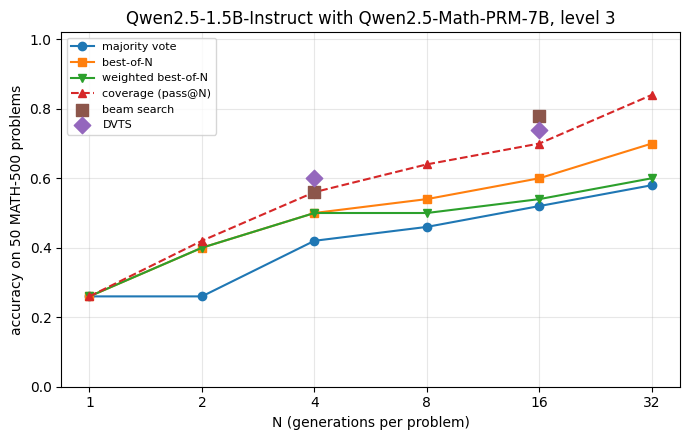

In [16]:
plt.figure(figsize=(7, 4.5))
for (name, values), marker in zip(curves.items(), "osv^"):
    plt.plot(NS, values, marker=marker, label=name, linestyle="--" if "coverage" in name else "-")
for (name, n), result in search.items():
    plt.scatter([n], [result["accuracy"]], marker="D" if name == "DVTS" else "s", s=70,
                color="C4" if name == "DVTS" else "C5", label=name if n == SEARCH_NS[0] else None, zorder=3)
plt.xscale("log", base=2)
plt.xticks(NS, NS)
plt.xlabel("N (generations per problem)")
plt.ylabel(f"accuracy on {len(problems)} MATH-500 problems")
plt.ylim(0, 1.02)
plt.grid(alpha=0.3)
plt.legend(fontsize=8)
plt.title(f"{POLICY.split('/')[-1]} with {(PRM if USE_LARGE_PRM else PRM_SMALL).split('/')[-1]}, level {LEVEL}")
plt.tight_layout()
plt.show()

In [17]:
cost = pd.DataFrame(
    [{"method": f"{m}, N={n}", "accuracy": curves[m][NS.index(n)], "tokens per problem": tokens_per_sample * n}
     for m in ["majority vote", "weighted best-of-N"] for n in SEARCH_NS]
    + [{"method": f"{name}, N={n}", **result} for (name, n), result in search.items()])
cost.set_index("method").round(2)

,accuracy,tokens per problem
method,,
"majority vote, N=4",0.42,1195.73
"majority vote, N=16",0.52,4782.93
"weighted best-of-N, N=4",0.50,1195.73
"weighted best-of-N, N=16",0.54,4782.93
"beam search, N=4",0.56,1695.36
"beam search, N=16",0.78,6910.72
"DVTS, N=4",0.60,1603.22
"DVTS, N=16",0.74,6428.06


In [18]:
# A problem where the PRM-weighted vote and the plain vote disagree, if there is one.
n = NS[-1]
for entry, (_, gold) in zip(pool, problems):
    i_vote, i_weighted = select(entry, n, "majority vote"), select(entry, n, "weighted best-of-N")
    if i_vote is not None and i_weighted is not None and not verify(entry["answers"][i_vote], entry["answers"][i_weighted]):
        print("gold:", gold)
        print(f"majority vote picks {entry['answers'][i_vote]} (correct: {entry['correct'][i_vote]})")
        print(f"weighted vote picks {entry['answers'][i_weighted]} (correct: {entry['correct'][i_weighted]}, "
              f"PRM score {entry['score'][i_weighted]:.2f})")
        print("\nthe weighted choice, with its step scores:")
        for step, score in zip(steps_of(entry["texts"][i_weighted]), entry["steps"][i_weighted]):
            print(f"{score:.2f} | {step[:110]!r}")
        break
else:
    print("The two votes agree on every problem at this budget.")

gold: 2220
majority vote picks [222, '222'] (correct: False)
weighted vote picks [44444, '44444'] (correct: False, PRM score 0.97)

the weighted choice, with its step scores:
0.98 | 'Start from the smallest number greater than or equal to 1 that uses only the digits 0 and 2.'
0.97 | 'Find a way to combine numbers using addition such that you get multiples of 30.'
0.99 | 'The first multiple found will be the answer.'
0.09 | 'Therefore, the least positive integer multiple of 30 constructed with only the digits 0 and 2 is $6\\text{digit'
0.89 | "Let's check:"
0.27 | '$$2 = 2,$$\n$$2*2 = 4,$$\n$$2*4 = 8,$$\n$$2*8 = 16,$$\n$$2*16 + 2 = 34,$$\n$$2*34 + 2 = 66,$$\n$$2*66 + 2 = 134,$$\n$'
0.85 | "Let's try another approach by multiplying $12$ repeatedly until reaching a multiple of $30$:  "
0.91 | '$12$ multiplied once gives us:\n$$12.$$'
0.97 | 'Multiplying again,\n$$12*12=144,$$'
0.99 | "which also isn't a multiple of $30$."
0.97 | "Moving on, now let's consider multiplication involving more

**What to notice**

Coverage rises with $N$ and the selectors trail it: the gap below the dashed line is the selection gap, the right answers that are in the pool but not chosen. The majority vote converges to the model's most frequent answer and then flattens. The PRM can pick a minority answer, so best-of-N and the weighted vote move away from the plain vote as $N$ grows, and the weighted vote is usually the steadier of the two because one over-confident score cannot carry it alone.

Beam search spends its $N$ on fewer, better guided paths, so it is at its best at the small budgets. Where it falls behind the parallel methods at the same $N$, the PRM has been over-exploited: one high-scoring step pulled every beam into the same prefix. DVTS keeps its subtrees apart, which costs some exploitation and buys diversity. With fifty problems one problem is two points of accuracy, so read the curves as trends.

## Summary

- Test-time compute is generation plus selection: coverage grows with $N$ and the selector decides how much of it we keep.
- A process reward model gives one probability per step at a separator token, and the convention (which token, which chat format, which class) must match the model card exactly.
- Majority voting, best-of-N and weighted best-of-N read the same pool and differ only in how the scores enter the vote.
- Beam search and DVTS move the scorer inside generation, which helps most at small budgets and can over-exploit the scorer at large ones.

## Exercises

1. **Aggregation.** Set `AGG` to `"min"` and rerun the scoring and the parallel curves. Compare best-of-N and the weighted vote with the `"last"` curves.
2. **Difficulty.** Set `LEVEL` to 5 and rerun. Compare coverage and the gap between the vote and the PRM selectors with the level 3 run.
3. **Beam width.** Set `BEAM_WIDTH` to 2 with `SEARCH_NS = [4, 16]`. Compare the accuracy of beam search and DVTS at `N=16`, and the number of distinct first steps that survive.
4. **Depth.** Set `MAX_ITERATIONS` to 10 and `STEP_TOKENS` to 96. Compare the tokens per problem and the accuracy of beam search with the default run.
5. **Temperature.** Set `TEMPERATURE` to 0.4 and resample the pool. Compare coverage at `N=32` and the majority vote at `N=32` with the default run.

## Further Reading

- [Snell et al., 2024. Scaling LLM Test-Time Compute Optimally can be More Effective than Scaling Model Parameters](https://arxiv.org/abs/2408.03314)
- [Lightman et al., 2023. Let's Verify Step by Step](https://arxiv.org/abs/2305.20050)
- [Zhang et al., 2025. The Lessons of Developing Process Reward Models in Mathematical Reasoning](https://arxiv.org/abs/2501.07301)
- [Brown et al., 2024. Large Language Monkeys: Scaling Inference Compute with Repeated Sampling](https://arxiv.org/abs/2407.21787)
- [Wang et al., 2022. Self-Consistency Improves Chain of Thought Reasoning in Language Models](https://arxiv.org/abs/2203.11171)

### Contributed by: Mohamed Eltayeb